# Capstone Project: Klasifikasi Kesegaran Daging
Notebook ini mencakup alur pipeline lengkap:
1. Persiapan Data (Preprocessing & Augmentasi)
2. Training Model (MobileNetV2 vs VGG16)
3. Evaluasi (Perbandingan Metrik dan Grafik)
4. Penyimpanan Model Terbaik

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

base_dir = '../dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

## 1. Persiapan Data (Data Preparation & Augmentation)

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1815 images belonging to 3 classes.
Found 451 images belonging to 3 classes.


## 2. Training Model MobileNetV2 (Baseline)

In [3]:
base_model_1 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_1.layers:
    layer.trainable = False

x1 = base_model_1.output
x1 = GlobalAveragePooling2D()(x1)
x1 = Dense(128, activation='relu')(x1)
x1 = Dropout(0.5)(x1)
predictions_1 = Dense(3, activation='softmax')(x1)

model_mobilenet = Model(inputs=base_model_1.input, outputs=predictions_1)
model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = model_mobilenet.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.4898 - loss: 1.1029 - val_accuracy: 0.7184 - val_loss: 0.6640
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.6457 - loss: 0.7477 - val_accuracy: 0.7938 - val_loss: 0.5258
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7041 - loss: 0.6264 - val_accuracy: 0.8426 - val_loss: 0.4456
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7614 - loss: 0.5355 - val_accuracy: 0.8271 - val_loss: 0.4166
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7868 - loss: 0.4942 - val_accuracy: 0.8271 - val_loss: 0.4003
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8039 - loss: 0.4579 - val_accuracy: 0.8869 - val_loss: 0.3418
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 994ms/step - accuracy: 0.8044 - loss: 0.4394 - val_accuracy: 0.8670 - val_loss: 0.3256
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 996ms/step - accuracy: 0.8226 - loss: 0.4173 - val_accuracy: 0.8714 - v

## 3. Training Model VGG16 (Pembanding)

In [4]:
base_model_2 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_2.layers:
    layer.trainable = False

x2 = base_model_2.output
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(128, activation='relu')(x2)
x2 = Dropout(0.5)(x2)
predictions_2 = Dense(3, activation='softmax')(x2)

model_vgg = Model(inputs=base_model_2.input, outputs=predictions_2)
model_vgg.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = model_vgg.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 478s 8s/step - accuracy: 0.3587 - loss: 1.2063 - val_accuracy: 0.4945 - val_loss: 1.0275
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 495s 9s/step - accuracy: 0.3939 - loss: 1.1035 - val_accuracy: 0.6585 - val_loss: 0.9692
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 477s 8s/step - accuracy: 0.4446 - loss: 1.0266 - val_accuracy: 0.6674 - val_loss: 0.9240
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 490s 9s/step - accuracy: 0.5036 - loss: 0.9676 - val_accuracy: 0.7051 - val_loss: 0.8790
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 527s 9s/step - accuracy: 0.5515 - loss: 0.9292 - val_accuracy: 0.6741 - val_loss: 0.8433
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 554s 10s/step - accuracy: 0.5708 - loss: 0.8777 - val_accuracy: 0.7118 - val_loss: 0.8109
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 488s 9s/step - accuracy: 0.6248 - loss: 0.8419 - val_accuracy: 0.7472 - val_loss: 0.7780
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 476s 8s/step - accuracy: 0.6248 - loss: 0.8184 - val_accuracy: 0.6984 - 

## 4. Evaluasi Model (Visualisasi Perbandingan Grafik)

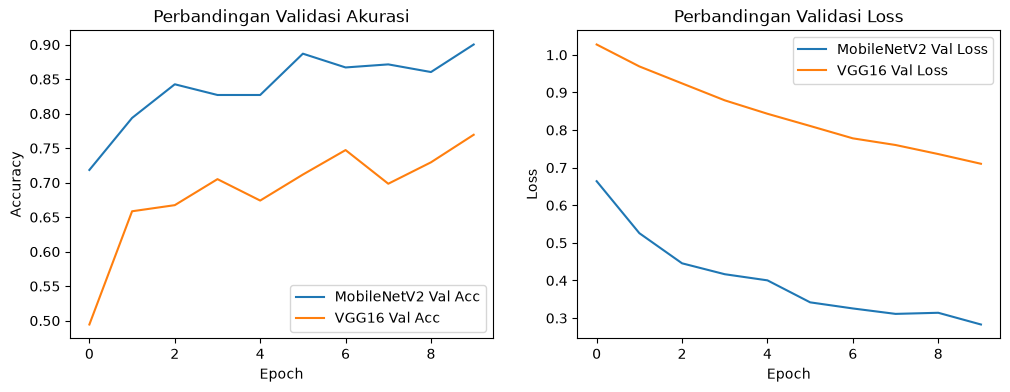

In [5]:
def plot_comparison(hist1, hist2, title):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(hist1.history['val_accuracy'], label='MobileNetV2 Val Acc')
    plt.plot(hist2.history['val_accuracy'], label='VGG16 Val Acc')
    plt.title('Perbandingan Validasi Akurasi')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(hist1.history['val_loss'], label='MobileNetV2 Val Loss')
    plt.plot(hist2.history['val_loss'], label='VGG16 Val Loss')
    plt.title('Perbandingan Validasi Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_comparison(history_mobilenet, history_vgg, "Perbandingan MobileNetV2 vs VGG16")

## 5. Simpan Model Terbaik

In [6]:
import os
os.makedirs('../models', exist_ok=True)
# Menyimpan model dengan ekstensi .h5 yang akan diload oleh app.py
model_mobilenet.save('../models/best_model.h5')
print("Model berhasil disimpan!")

Model berhasil disimpan!
